In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [11]:
orders = pd.read_csv("orders.csv", parse_dates = ["order_date"])
customers = pd.read_csv("customers.csv", parse_dates = ["signup_date"])
products = pd.read_csv("products.csv")

orders["revenue"] = orders["price"]*orders["quantity"]
df = (orders.merge(customers, on = "customer_id", how = "left")
      .merge(products, on = "product_id", how = "left", suffixes = ("","_prod")))
df["brand"] = df["brand"].fillna("unknown")

### Using Seaborn as sns to show graph

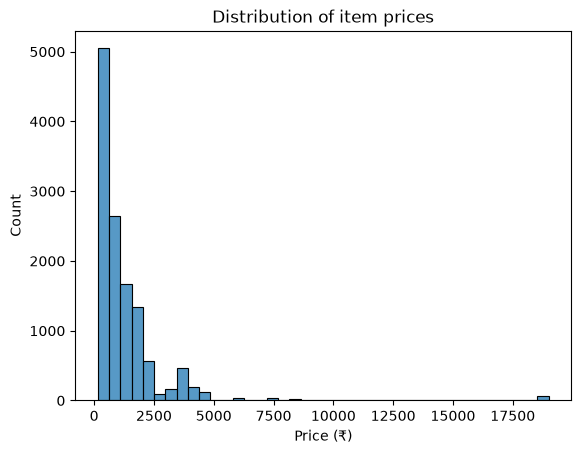

In [12]:
sns.histplot(df["price"], bins=40)
plt.xlabel("Price (₹)")
plt.title("Distribution of item prices")
plt.show()

### Finding mean, median & skew 

In [17]:
print(f'Mean: {round(df["price"].mean(), 2)}')
print(f'Median: {df["price"].median()}')
print(f'Skew: {round(df["price"].skew(),2)}')

Mean: 1274.49
Median: 776.0
Skew: 6.44


### Finding correlation in data

In [19]:
num_cols = ["price", "quantity", "revenue", "rating"]
df[num_cols].corr().round(2)

,price,quantity,revenue,rating
price,1.00,-0.21,0.90,0.09
quantity,-0.21,1.00,0.07,-0.02
revenue,0.90,0.07,1.00,0.08
rating,0.09,-0.02,0.08,1.00


### Making a bar chart using seaborn library

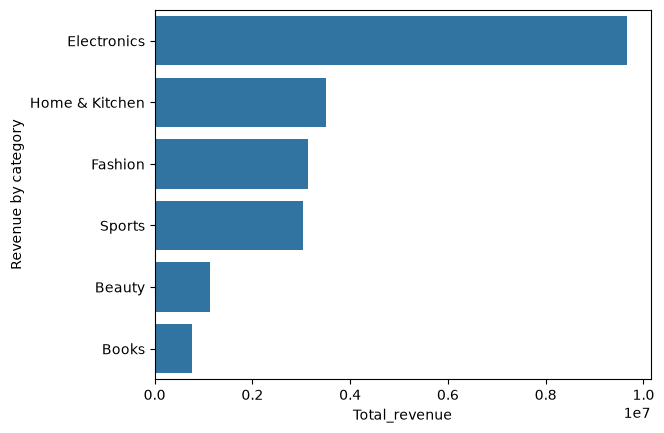

In [30]:
cat_rev = orders.groupby("category")["revenue"].sum().sort_values(ascending = False)

sns.barplot(x = cat_rev.values, y = cat_rev.index) #use , color = "green" inside parenthesis
plt.xlabel("Total_revenue")
plt.ylabel("Revenue by category")
plt.show()

### Making a line chart

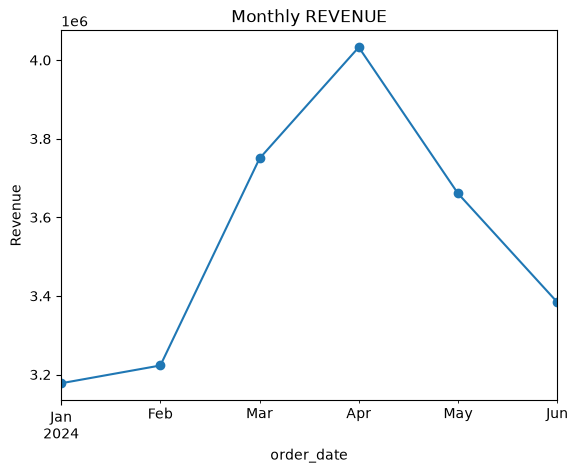

In [35]:
monthly = (df.set_index("order_date").resample("ME")["revenue"].sum())
monthly.plot(marker =  "o")
plt.ylabel("Revenue")
plt.title("Monthly REVENUE")
plt.show()

### Cohorts Intuition

In [52]:
df["signup_month"] = df["signup_date"].dt.to_period("M")

cohorts = df.groupby("signup_month")["revenue"].mean().round(0)
cohorts.tail(5)

signup_month
2024-01    1579.0
2024-02    2029.0
2024-03    1799.0
2024-04    1374.0
2024-05    1449.0
Freq: M, Name: revenue, dtype: float64

## RFM (
### Recency(last order day),
### Frequency(how many orders), 
### Monetary(revenue from that customer))

In [71]:
snapshot = orders["order_date"].max() + pd.Timedelta(days=1) # max orderdate + 1

rfm = orders.groupby("customer_id").agg(
    recency=("order_date", lambda d: (snapshot - d.max()).days), # d represents all the orderdates and 
    #.day : Converts 1 day 00:00:00 to the integer 1.
    frequency=("order_id", "nunique"),
    monetary=("revenue", lambda x:x.sum()),
).reset_index()

rfm.head(8)

,customer_id,recency,frequency,monetary
0,CUST001,4,3,1893.0
1,CUST002,5,12,19561.0
2,CUST003,7,8,22474.0
3,CUST004,90,2,4373.0
4,CUST006,37,5,17170.0
5,CUST007,82,4,9571.0
6,CUST008,33,5,14478.0
7,CUST009,6,9,14947.0


#### know how lambda function works in python

In [69]:
#syntax
     # lambda arg1,arg2 : operation
add = lambda x,y : x+y
print(f'addition : {add(25,6)}')

addition : 31
